# Session 2: Model Optimisation Techniques

**Module 5: Deep Learning in Production**  
SMU Advanced Certificate in Generative AI and Deep Learning

---

**Duration:** 1 hour (20 min theory, 40 min hands-on)  
**Prerequisites:** Basic Python and PyTorch knowledge from prior modules  

**Learning Objectives:**
- Understand why model optimisation matters for production deployment
- Learn three key techniques: **Quantisation**, **Pruning**, and **Knowledge Distillation**
- Apply quantisation and pruning to a real model and measure the impact
- Compare trade-offs between model size, speed, and accuracy

---

## Setup

Run the cell below to install and import all required packages.

In [1]:
# Install required packages (uncomment if needed)
# !pip install torch torchvision matplotlib Pillow tabulate

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.quantization import quantize_dynamic, QuantStub, DeQuantStub
import torch.nn.utils.prune as prune
import time
import os
import tempfile
import copy
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.10.0+cu128
Device: cuda


---

# Part 1: Theory (~20 minutes)

---

## 1.1 Why Optimise Models?

In Module 5 Session 1, we discussed the journey from training a model to deploying it. But here is a common problem:

> Your model works great on your GPU workstation, but it is **too large**, **too slow**, or **too expensive** to run in production.

### Production Constraints

| Constraint | Description | Example |
|---|---|---|
| **Memory limits** | Devices have finite RAM/VRAM | A mobile phone has 4-8 GB total RAM |
| **Latency requirements** | Users expect fast responses | A chatbot must respond in < 200ms |
| **Cost** | Cloud GPU time is expensive | Running GPT-scale models costs \$1000s/day |
| **Energy/Battery** | Edge devices have limited power | Drones, IoT sensors, wearables |

### The Fundamental Trade-off

```
Model Accuracy  <=========>  Speed / Size / Cost
   (higher)                     (lower)
```

The goal of model optimisation is to **reduce size and improve speed** while **losing as little accuracy as possible**.

### Deployment Scenarios

| Scenario | Typical Constraints | Optimisation Priority |
|---|---|---|
| **Cloud server** | Cost, throughput | Moderate — quantisation for cost savings |
| **Mobile app** | Size (< 50 MB), latency, battery | Aggressive — all techniques combined |
| **Edge device** (Raspberry Pi, drone) | Tiny memory (< 1 GB), no GPU | Very aggressive — smallest possible model |
| **Web browser** (ONNX.js, TF.js) | Download size, JS runtime speed | Size is critical |

---

**Key Concept:** Model optimisation is not about making a "worse" model. It is about removing **redundancy** — most large models have far more capacity than they need for a given task.

## 1.2 Quantisation

### What Is Quantisation?

Quantisation reduces the **numerical precision** of model weights and activations. Instead of storing every weight as a 32-bit floating point number, we use fewer bits.

```
FP32 (32-bit float)     High precision, large size      ████████████████████████████████
FP16 (16-bit float)     Good precision, half size        ████████████████
INT8 (8-bit integer)    Lower precision, quarter size    ████████
INT4 (4-bit integer)    Least precision, 1/8 size        ████
```

### How Precision Reduction Works

Imagine you have a weight value of **0.7834521**:

| Precision | Stored Value | Bits | Error |
|---|---|---|---|
| FP32 | 0.7834521 | 32 | 0 |
| FP16 | 0.7832 | 16 | ~0.0002 |
| INT8 | 0.78 (mapped to integer 200 out of 0-255) | 8 | ~0.003 |

For a single weight, this error is tiny. Across millions of weights, the errors mostly cancel out, so the model still works well.

### Types of Quantisation

| Type | How It Works | When to Use |
|---|---|---|
| **Dynamic Quantisation** | Weights are quantised ahead of time; activations are quantised on-the-fly during inference | Simplest to apply; good for LSTMs, Transformers, linear layers |
| **Static Quantisation** | Both weights and activations are quantised ahead of time, using a calibration dataset | Better speedup than dynamic; needs a representative dataset |
| **Quantisation-Aware Training (QAT)** | Model is trained with simulated quantisation, so it learns to be robust to lower precision | Best accuracy; requires retraining |

### Pros and Cons

| Pros | Cons |
|---|---|
| 2-4x model size reduction | Small accuracy loss (usually < 1%) |
| Faster inference (especially on CPU) | Not all operations support quantisation |
| No retraining needed (for post-training) | Hardware-dependent speed gains |
| Works with most model architectures | INT8 may cause issues on some models |

---

**Key Concept:** Quantisation is often the **first technique to try** because it gives significant size reduction with minimal effort and minimal accuracy loss.

## 1.3 Pruning

### What Is Pruning?

Pruning removes **unnecessary weights or neurons** from a neural network. The idea comes from a well-known observation:

> Many weights in a trained neural network are **very close to zero** and contribute almost nothing to the output.

```
Before pruning:          After pruning:

  O---O---O              O   O   O
 /|\X/|\X/|\            / \ / \   |
O-O-O-O-O-O-O          O   O   O   O
 \|/X\|/X\|/              \ |   | /
  O---O---O                O   O   O

(all connections)        (only important ones)
```

### Types of Pruning

| Type | What Gets Removed | Effect |
|---|---|---|
| **Unstructured pruning** | Individual weights (set to zero) | High sparsity, but irregular memory pattern |
| **Structured pruning** | Entire neurons, filters, or channels | Lower sparsity, but real speedup on hardware |

**Analogy:** Think of a company reorganisation:
- **Unstructured pruning** = Removing individual tasks from everyone's to-do list
- **Structured pruning** = Eliminating entire departments

### Pros and Cons

| Pros | Cons |
|---|---|
| Can remove 50-90% of weights | Unstructured pruning may not speed up inference without special hardware |
| Reveals what the model actually needs | May need fine-tuning after aggressive pruning |
| Can be combined with quantisation | Structured pruning changes model architecture |

---

**Key Concept:** Pruning is most effective when combined with other techniques. A common pipeline is: **Train -> Prune -> Fine-tune -> Quantise**.

## 1.4 Knowledge Distillation

### What Is Knowledge Distillation?

Knowledge distillation trains a **smaller "student" model** to mimic a **larger "teacher" model**.

```
┌─────────────────┐         ┌─────────────────┐
│  Teacher Model   │         │  Student Model   │
│  (Large, Slow)   │  ────>  │  (Small, Fast)   │
│  ResNet-152      │ "teach" │  ResNet-18       │
│  340 MB          │         │  45 MB           │
│  95% accuracy    │         │  93% accuracy    │
└─────────────────┘         └─────────────────┘
```

### Why Does It Work?

The key insight is about **soft labels** vs **hard labels**:

| Type | Example (classifying an image) | Information Content |
|---|---|---|
| **Hard label** | "cat" (one-hot: [0, 1, 0, 0]) | Minimal — just the answer |
| **Soft label** (teacher output) | [0.01, 0.85, 0.10, 0.04] (cat=85%, dog=10%, ...) | Rich — captures similarities between classes |

The soft labels tell the student that a cat is **somewhat similar to a dog** but **very different from a car**. This extra information helps the student learn more efficiently.

### Real-World Example: DistilBERT

| Model | Parameters | Speed | Accuracy (GLUE) |
|---|---|---|---|
| BERT-base | 110M | 1x | 100% (baseline) |
| **DistilBERT** | 66M (40% smaller) | 1.6x faster | 97% of BERT |

DistilBERT is used widely in production because it is nearly as good as BERT at a fraction of the cost.

### Pros and Cons

| Pros | Cons |
|---|---|
| Can dramatically reduce model size | Requires a trained teacher model |
| Student can have a completely different architecture | Training pipeline is more complex |
| Produces a genuinely smaller model (not just compressed) | Needs a training dataset |
| Often better than training the small model alone | Hyperparameter tuning (temperature, loss weight) |

---

**Note:** We will not implement knowledge distillation hands-on in this session because it requires a full training loop. However, it is important to understand as a concept, and many production models you will use (like DistilBERT) were created this way.

## 1.5 Comparison of All Three Techniques

| Aspect | Quantisation | Pruning | Knowledge Distillation |
|---|---|---|---|
| **What it does** | Reduces numerical precision | Removes unnecessary weights | Trains a smaller model to mimic a larger one |
| **Typical size reduction** | 2-4x | 2-10x (with structured pruning) | Depends on student architecture |
| **Speed improvement** | 1.5-3x (CPU) | Variable (needs sparse hardware) | Depends on student architecture |
| **Accuracy impact** | Minimal (< 1% loss) | Small to moderate | Small (often < 3% loss) |
| **Complexity** | Low (a few lines of code) | Medium | High (requires retraining) |
| **Requires retraining?** | No (post-training) / Yes (QAT) | Optional fine-tuning | Yes |
| **Best for** | Quick wins, CPU deployment | Reducing redundant parameters | Maximum compression, custom architectures |
| **Can combine with others?** | Yes | Yes | Yes |

---

**Key Concept:** These techniques are **complementary, not competing**. In production, teams often combine all three: distil a large model into a smaller one, prune the student, then quantise the result.

---

# Part 2: Hands-on Exercises (~40 minutes)

Now let us put these techniques into practice. We will optimise a **ResNet-18** image classification model and measure the impact of each technique.

---

## Helper Functions

First, let us define some utility functions that we will reuse throughout the exercises.

In [3]:
def get_model_size_mb(model):
    """Save the model to a temporary file and measure its size in MB."""
    with tempfile.NamedTemporaryFile(delete=True, suffix='.pt') as tmp:
        torch.save(model.state_dict(), tmp.name)
        size_mb = os.path.getsize(tmp.name) / (1024 * 1024)
    return size_mb


def measure_inference_time(model, input_tensor, num_runs=50):
    """Measure average inference time over multiple runs.
    
    We run the model multiple times and take the average to get
    a stable measurement. The first few runs are discarded as
    warm-up to avoid measuring one-time setup costs.
    """
    model.eval()
    
    # Warm-up runs (not measured)
    with torch.no_grad():
        for _ in range(5):
            _ = model(input_tensor)
    
    # Timed runs
    times = []
    with torch.no_grad():
        for _ in range(num_runs):
            start = time.perf_counter()
            _ = model(input_tensor)
            end = time.perf_counter()
            times.append((end - start) * 1000)  # Convert to ms
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time


def count_parameters(model):
    """Count total and non-zero parameters in the model."""
    total = 0
    nonzero = 0
    for param in model.parameters():
        total += param.numel()
        nonzero += param.count_nonzero().item()
    return total, nonzero


def get_top5_predictions(model, input_tensor, class_labels):
    """Get the top 5 predicted classes with their probabilities."""
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        top5_prob, top5_idx = torch.topk(probabilities, 5)
    
    results = []
    for i in range(5):
        idx = top5_idx[i].item()
        label = class_labels[idx] if idx < len(class_labels) else f"Class {idx}"
        results.append((label, top5_prob[i].item() * 100))
    return results


print("Helper functions defined successfully.")

Helper functions defined successfully.


---

## Exercise 1: Baseline Model

Let us start by loading a pre-trained ResNet-18 and establishing baseline measurements.

**ResNet-18** is a relatively small convolutional neural network with ~11.7 million parameters. It was trained on ImageNet (1000 classes) and is a great model for learning optimisation techniques because it is small enough to work with quickly.

### Step 1: Load the model and prepare a sample input

In [4]:
# Load a pre-trained ResNet-18 model
# 'weights' parameter loads the ImageNet-trained weights
baseline_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
baseline_model.eval()  # Set to evaluation mode (not training)

# Create a sample input tensor
# ResNet expects images of shape (batch, channels, height, width) = (1, 3, 224, 224)
sample_input = torch.randn(1, 3, 224, 224)

print(f"Model: ResNet-18")
print(f"Input shape: {sample_input.shape}")
print(f"Output shape: {baseline_model(sample_input).shape}  (1000 ImageNet classes)")

Model: ResNet-18
Input shape: torch.Size([1, 3, 224, 224])


Output shape: torch.Size([1, 1000])  (1000 ImageNet classes)


### Step 2: Download ImageNet class labels

We will use these labels to interpret the model's predictions.

In [5]:
# Use the built-in class labels from torchvision
class_labels = models.ResNet18_Weights.DEFAULT.meta["categories"]
print(f"Number of classes: {len(class_labels)}")
print(f"First 10 classes: {class_labels[:10]}")

Number of classes: 1000
First 10 classes: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


### Step 3: Measure baseline metrics

In [6]:
# Measure model size
baseline_size = get_model_size_mb(baseline_model)
print(f"Model size: {baseline_size:.2f} MB")

# Count parameters
total_params, nonzero_params = count_parameters(baseline_model)
print(f"Total parameters: {total_params:,}")
print(f"Non-zero parameters: {nonzero_params:,}")

# Measure inference time
baseline_time, baseline_std = measure_inference_time(baseline_model, sample_input)
print(f"Average inference time: {baseline_time:.2f} +/- {baseline_std:.2f} ms")

# Get predictions on the sample input
baseline_preds = get_top5_predictions(baseline_model, sample_input, class_labels)
print("\nTop 5 predictions on random input:")
for label, prob in baseline_preds:
    print(f"  {label}: {prob:.2f}%")

Model size: 44.67 MB
Total parameters: 11,689,512
Non-zero parameters: 11,689,512


Average inference time: 45.99 +/- 149.70 ms

Top 5 predictions on random input:
  jellyfish: 28.01%
  jigsaw puzzle: 6.31%
  sea snake: 4.14%
  nematode: 3.58%
  hammerhead: 2.23%


---

**Note:** Since we are using a random tensor as input (not a real image), the predictions will not be meaningful. The important thing is that we can **compare** the predictions before and after optimisation to verify the model still produces similar outputs.

---

## Exercise 2: Dynamic Quantisation

Dynamic quantisation is the **simplest** form of quantisation. It quantises the weights to INT8 ahead of time and quantises activations dynamically during inference.

In PyTorch, it takes just **one line of code**.

### Step 1: Apply dynamic quantisation

In [7]:
# Apply dynamic quantisation to Linear layers
# This converts FP32 weights in Linear layers to INT8
dynamic_quantised_model = quantize_dynamic(
    model=copy.deepcopy(baseline_model),  # Work on a copy, keep the original
    qconfig_spec={nn.Linear},             # Which layer types to quantise
    dtype=torch.qint8                     # Target precision
)

print("Dynamic quantisation applied successfully!")
print(f"\nOriginal fc layer:")
print(f"  {baseline_model.fc}")
print(f"\nQuantised fc layer:")
print(f"  {dynamic_quantised_model.fc}")

Dynamic quantisation applied successfully!

Original fc layer:
  Linear(in_features=512, out_features=1000, bias=True)

Quantised fc layer:
  DynamicQuantizedLinear(in_features=512, out_features=1000, dtype=torch.qint8, qscheme=torch.per_tensor_affine)


### Step 2: Measure the quantised model

In [8]:
# Measure quantised model size
dq_size = get_model_size_mb(dynamic_quantised_model)
print(f"Model size: {dq_size:.2f} MB (was {baseline_size:.2f} MB)")
print(f"Size reduction: {(1 - dq_size / baseline_size) * 100:.1f}%")

# Measure inference time
dq_time, dq_std = measure_inference_time(dynamic_quantised_model, sample_input)
print(f"\nAverage inference time: {dq_time:.2f} +/- {dq_std:.2f} ms")
print(f"Speed change: {(1 - dq_time / baseline_time) * 100:+.1f}%")

Model size: 43.20 MB (was 44.67 MB)
Size reduction: 3.3%



Average inference time: 4.59 +/- 0.70 ms
Speed change: +90.0%


### Step 3: Compare predictions

In [9]:
# Compare predictions between original and dynamically quantised model
dq_preds = get_top5_predictions(dynamic_quantised_model, sample_input, class_labels)

print("Prediction Comparison (Dynamic Quantisation)")
print("=" * 60)
headers = ["Rank", "Original", "Prob (%)", "Quantised", "Prob (%)"]
rows = []
for i in range(5):
    rows.append([
        i + 1,
        baseline_preds[i][0],
        f"{baseline_preds[i][1]:.2f}",
        dq_preds[i][0],
        f"{dq_preds[i][1]:.2f}"
    ])
print(tabulate(rows, headers=headers, tablefmt="grid"))

Prediction Comparison (Dynamic Quantisation)
+--------+---------------+------------+---------------+------------+
|   Rank | Original      |   Prob (%) | Quantised     |   Prob (%) |
+========+===============+============+===============+============+
|      1 | jellyfish     |      28.01 | jellyfish     |      29.08 |
+--------+---------------+------------+---------------+------------+
|      2 | jigsaw puzzle |       6.31 | jigsaw puzzle |       6.52 |
+--------+---------------+------------+---------------+------------+
|      3 | sea snake     |       4.14 | sea snake     |       4.09 |
+--------+---------------+------------+---------------+------------+
|      4 | nematode      |       3.58 | nematode      |       3.51 |
+--------+---------------+------------+---------------+------------+
|      5 | hammerhead    |       2.23 | hammerhead    |       2.23 |
+--------+---------------+------------+---------------+------------+


---

**Note:** For ResNet-18, dynamic quantisation mainly affects the final fully connected (`fc`) layer. Since most computation in ResNet happens in convolutional layers, the size and speed gains from dynamic quantisation alone are modest. Static quantisation (next exercise) will quantise the convolutional layers too.

---

## Exercise 3: Static Quantisation (Walkthrough)

Static quantisation is more powerful than dynamic quantisation because it quantises **both weights and activations** ahead of time. However, it needs a **calibration dataset** so it can figure out the typical range of activation values.

The process has four steps:
1. **Prepare** the model by inserting quantisation/dequantisation stubs
2. **Set** the quantisation configuration (backend, observer type)
3. **Calibrate** by running representative data through the model
4. **Convert** the model to its quantised form

### Step 1: Prepare the model

In [10]:
# We need to wrap ResNet-18 with QuantStub/DeQuantStub
# These mark where quantisation and dequantisation should happen

class QuantizableResNet18(nn.Module):
    """Wrapper around ResNet-18 that adds quantisation stubs."""
    
    def __init__(self, original_model):
        super().__init__()
        self.quant = QuantStub()      # Converts FP32 input to quantised
        self.model = original_model   # The actual ResNet-18
        self.dequant = DeQuantStub()  # Converts quantised output back to FP32
    
    def forward(self, x):
        x = self.quant(x)       # Quantise the input
        x = self.model(x)       # Run through ResNet-18
        x = self.dequant(x)     # Dequantise the output
        return x


# Create a copy and wrap it
static_model = QuantizableResNet18(copy.deepcopy(baseline_model))
static_model.eval()

print("Quantisable model created.")
print(f"Model structure: QuantStub -> ResNet18 -> DeQuantStub")

Quantisable model created.
Model structure: QuantStub -> ResNet18 -> DeQuantStub


### Step 2: Set quantisation configuration and prepare

In [11]:
# Select the quantisation backend
# 'x86' for Intel CPUs (most laptops/desktops)
# 'qnnpack' for ARM CPUs (mobile devices, Raspberry Pi)
backend = 'x86'  # Change to 'qnnpack' if on ARM
static_model.qconfig = torch.quantization.get_default_qconfig(backend)
torch.backends.quantized.engine = backend

# Prepare the model for static quantisation
# This inserts observers that will record the range of activations
torch.quantization.prepare(static_model, inplace=True)

print(f"Quantisation backend: {backend}")
print("Model prepared for calibration.")
print("Observers have been inserted to track activation ranges.")

Quantisation backend: x86
Model prepared for calibration.
Observers have been inserted to track activation ranges.


### Step 3: Calibrate with sample data

In a real scenario, you would use a representative subset of your training/validation data. Here we will use a few random tensors as a simplified demonstration.

In [12]:
# Calibration: run representative data through the model
# The observers record the min/max values of activations at each layer
print("Running calibration...")
num_calibration_samples = 20

with torch.no_grad():
    for i in range(num_calibration_samples):
        # In production, use real images here!
        calibration_input = torch.randn(1, 3, 224, 224)
        static_model(calibration_input)

print(f"Calibration complete with {num_calibration_samples} samples.")
print("Observers have recorded the activation ranges.")

Running calibration...


Calibration complete with 20 samples.
Observers have recorded the activation ranges.


### Step 4: Convert to quantised model

In [13]:
# Convert the model: replace observed layers with quantised versions
torch.quantization.convert(static_model, inplace=True)

print("Static quantisation conversion complete!")

Static quantisation conversion complete!


### Step 5: Measure static quantised model

In [14]:
# Measure static quantised model
sq_size = get_model_size_mb(static_model)
sq_time, sq_std = measure_inference_time(static_model, sample_input)

print("Static Quantisation Results")
print("=" * 50)
print(f"Model size:      {sq_size:.2f} MB (original: {baseline_size:.2f} MB)")
print(f"Size reduction:  {(1 - sq_size / baseline_size) * 100:.1f}%")
print(f"Inference time:  {sq_time:.2f} +/- {sq_std:.2f} ms")
print(f"Speed change:    {(1 - sq_time / baseline_time) * 100:+.1f}%")

# Compare with dynamic quantisation
print("\nComparison with Dynamic Quantisation:")
headers = ["Metric", "Baseline", "Dynamic Quant", "Static Quant"]
rows = [
    ["Size (MB)", f"{baseline_size:.2f}", f"{dq_size:.2f}", f"{sq_size:.2f}"],
    ["Inference (ms)", f"{baseline_time:.2f}", f"{dq_time:.2f}", f"{sq_time:.2f}"],
]
print(tabulate(rows, headers=headers, tablefmt="grid"))

NotImplementedError: Could not run 'aten::add.out' with arguments from the 'QuantizedCPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'aten::add.out' is only available for these backends: [CPU, CUDA, Meta, MkldnnCPU, SparseCPU, SparseCUDA, SparseMeta, SparseCsrCPU, SparseCsrCUDA, SparseCsrMeta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradHIP, AutogradXLA, AutogradMPS, AutogradIPU, AutogradXPU, AutogradHPU, AutogradVE, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradPrivateUse2, AutogradPrivateUse3, AutogradMeta, AutogradNestedTensor, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastXPU, Autocas

---

**Key Concept:** Static quantisation typically provides **better size reduction and speed gains** than dynamic quantisation because it quantises the convolutional layers too, not just the linear layers. The trade-off is that it requires a calibration step.

---

## Exercise 4: Pruning a Model

Now let us try pruning. We will apply **unstructured pruning** to the convolutional layers of ResNet-18. This sets a percentage of the smallest weights to zero.

### Step 1: Apply unstructured pruning

In [15]:
# Create a fresh copy of the baseline model for pruning
pruned_model = copy.deepcopy(baseline_model)
pruned_model.eval()

# Define the pruning amount (50% of weights will be set to zero)
pruning_amount = 0.5

# Apply L1 unstructured pruning to all Conv2d layers
# L1 pruning removes the weights with the smallest absolute values
layers_pruned = 0
for name, module in pruned_model.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.l1_unstructured(module, name='weight', amount=pruning_amount)
        layers_pruned += 1

print(f"Applied {pruning_amount*100:.0f}% L1 unstructured pruning to {layers_pruned} Conv2d layers.")

Applied 50% L1 unstructured pruning to 20 Conv2d layers.


### Step 2: Inspect the sparsity

In [16]:
# Let us look at the sparsity of each pruned layer
print("Layer Sparsity After Pruning")
print("=" * 65)

layer_data = []
total_weights = 0
total_zeros = 0

for name, module in pruned_model.named_modules():
    if isinstance(module, nn.Conv2d):
        # Count zeros in the weight tensor
        weight = module.weight
        num_elements = weight.numel()
        num_zeros = (weight == 0).sum().item()
        sparsity = num_zeros / num_elements * 100
        
        total_weights += num_elements
        total_zeros += num_zeros
        
        layer_data.append([name, num_elements, num_zeros, f"{sparsity:.1f}%"])

headers = ["Layer", "Total Weights", "Zero Weights", "Sparsity"]
print(tabulate(layer_data, headers=headers, tablefmt="grid"))
print(f"\nOverall sparsity: {total_zeros / total_weights * 100:.1f}%")
print(f"({total_zeros:,} out of {total_weights:,} weights are zero)")

Layer Sparsity After Pruning
+-----------------------+-----------------+----------------+------------+
| Layer                 |   Total Weights |   Zero Weights | Sparsity   |
+=======================+=================+================+============+
| conv1                 |            9408 |           4704 | 50.0%      |
+-----------------------+-----------------+----------------+------------+
| layer1.0.conv1        |           36864 |          18432 | 50.0%      |
+-----------------------+-----------------+----------------+------------+
| layer1.0.conv2        |           36864 |          18432 | 50.0%      |
+-----------------------+-----------------+----------------+------------+
| layer1.1.conv1        |           36864 |          18432 | 50.0%      |
+-----------------------+-----------------+----------------+------------+
| layer1.1.conv2        |           36864 |          18432 | 50.0%      |
+-----------------------+-----------------+----------------+------------+
| layer2.

### Step 3: Make pruning permanent and measure

PyTorch pruning works by applying a mask. To make the pruning permanent (and get the size benefit), we need to remove the mask and apply it directly to the weights.

In [17]:
# Make pruning permanent by removing the reparameterisation
for name, module in pruned_model.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.remove(module, 'weight')

print("Pruning masks applied permanently.")

# Measure pruned model
pruned_size = get_model_size_mb(pruned_model)
pruned_time, pruned_std = measure_inference_time(pruned_model, sample_input)
pruned_total, pruned_nonzero = count_parameters(pruned_model)

print(f"\nPruned Model Metrics")
print("=" * 50)
print(f"Model size:      {pruned_size:.2f} MB (original: {baseline_size:.2f} MB)")
print(f"Size reduction:  {(1 - pruned_size / baseline_size) * 100:.1f}%")
print(f"Inference time:  {pruned_time:.2f} +/- {pruned_std:.2f} ms")
print(f"Speed change:    {(1 - pruned_time / baseline_time) * 100:+.1f}%")
print(f"Parameters:      {pruned_nonzero:,} non-zero / {pruned_total:,} total")
print(f"Sparsity:        {(1 - pruned_nonzero / pruned_total) * 100:.1f}%")

Pruning masks applied permanently.



Pruned Model Metrics
Model size:      44.67 MB (original: 44.67 MB)
Size reduction:  0.0%
Inference time:  5.96 +/- 1.95 ms
Speed change:    +87.0%
Parameters:      6,106,056 non-zero / 11,689,512 total
Sparsity:        47.8%


### Step 4: Visualise weight distributions

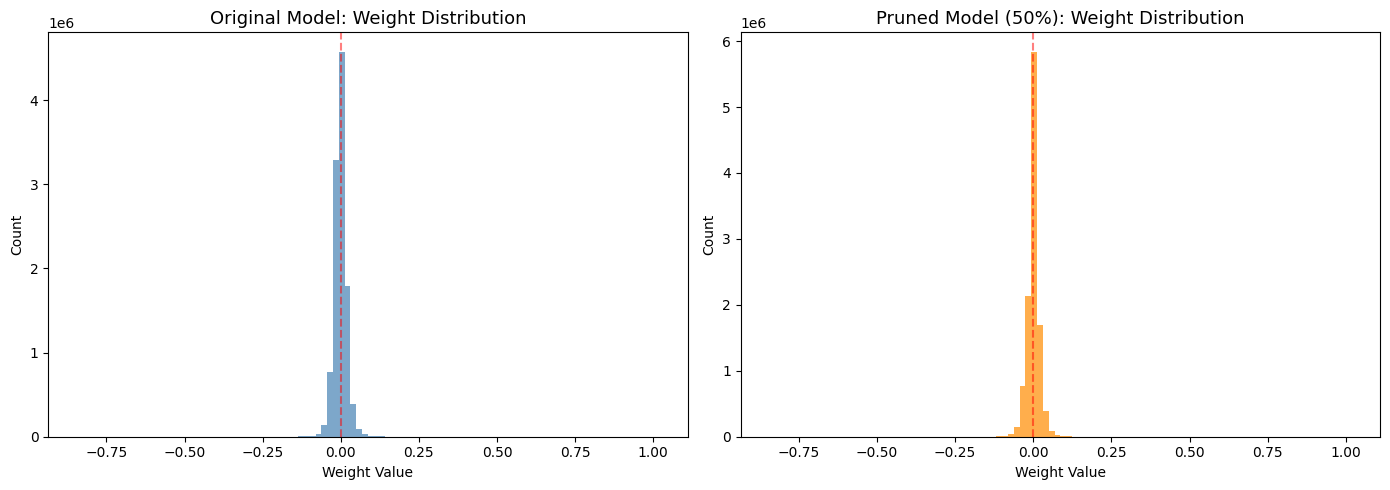

Notice the large spike at zero in the pruned model — those are the removed weights.


In [18]:
# Compare weight distributions before and after pruning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collect all Conv2d weights from baseline
baseline_weights = []
for module in baseline_model.modules():
    if isinstance(module, nn.Conv2d):
        baseline_weights.extend(module.weight.data.flatten().numpy())

# Collect all Conv2d weights from pruned model
pruned_weights = []
for module in pruned_model.modules():
    if isinstance(module, nn.Conv2d):
        pruned_weights.extend(module.weight.data.flatten().numpy())

# Plot baseline weights
axes[0].hist(baseline_weights, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
axes[0].set_title('Original Model: Weight Distribution', fontsize=13)
axes[0].set_xlabel('Weight Value')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Plot pruned weights (include zeros)
axes[1].hist(pruned_weights, bins=100, color='darkorange', alpha=0.7, edgecolor='none')
axes[1].set_title(f'Pruned Model ({pruning_amount*100:.0f}%): Weight Distribution', fontsize=13)
axes[1].set_xlabel('Weight Value')
axes[1].set_ylabel('Count')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Notice the large spike at zero in the pruned model — those are the removed weights.")

---

**Note:** You might notice that unstructured pruning does not reduce the file size much. This is because the zero weights are still stored in the tensor — they just happen to be zero. To get real size savings from pruning, you would need:
- **Sparse tensor formats** (which compress zeros)
- **Structured pruning** (which removes entire filters, changing the model architecture)
- **Combining pruning with quantisation** (the zeros compress very efficiently)

---

## Exercise 5: Side-by-Side Comparison

Let us bring everything together and compare all our models.

### Summary Table

In [19]:
# Build a comprehensive comparison table
print("\n" + "=" * 80)
print("         MODEL OPTIMISATION: SIDE-BY-SIDE COMPARISON")
print("=" * 80)

headers = [
    "Metric",
    "Baseline\n(FP32)",
    "Dynamic\nQuant (INT8)",
    "Static\nQuant (INT8)",
    "Pruned\n(50% sparse)"
]

rows = [
    [
        "Model Size (MB)",
        f"{baseline_size:.2f}",
        f"{dq_size:.2f}",
        f"{sq_size:.2f}",
        f"{pruned_size:.2f}"
    ],
    [
        "Size Reduction",
        "—",
        f"{(1 - dq_size / baseline_size) * 100:.1f}%",
        f"{(1 - sq_size / baseline_size) * 100:.1f}%",
        f"{(1 - pruned_size / baseline_size) * 100:.1f}%"
    ],
    [
        "Inference Time (ms)",
        f"{baseline_time:.2f}",
        f"{dq_time:.2f}",
        f"{sq_time:.2f}",
        f"{pruned_time:.2f}"
    ],
    [
        "Speed Change",
        "—",
        f"{(1 - dq_time / baseline_time) * 100:+.1f}%",
        f"{(1 - sq_time / baseline_time) * 100:+.1f}%",
        f"{(1 - pruned_time / baseline_time) * 100:+.1f}%"
    ],
    [
        "Complexity",
        "—",
        "Low (1 line)",
        "Medium (calibration)",
        "Medium"
    ],
]

print(tabulate(rows, headers=headers, tablefmt="grid"))


         MODEL OPTIMISATION: SIDE-BY-SIDE COMPARISON


NameError: name 'sq_time' is not defined

### Visual Comparison

NameError: name 'sq_time' is not defined

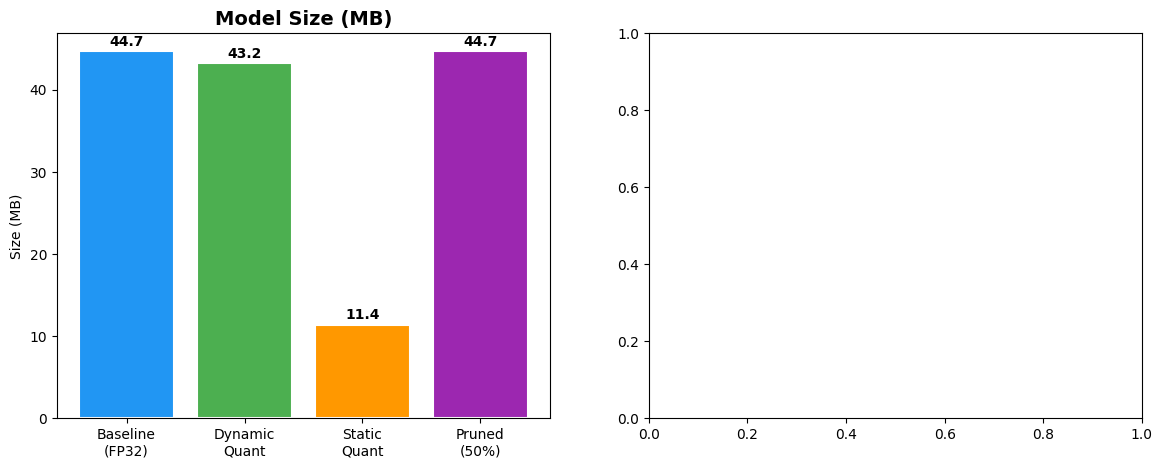

In [20]:
# Create a bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = ['Baseline\n(FP32)', 'Dynamic\nQuant', 'Static\nQuant', 'Pruned\n(50%)']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Model size comparison
sizes = [baseline_size, dq_size, sq_size, pruned_size]
bars1 = axes[0].bar(model_names, sizes, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Model Size (MB)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Size (MB)')
for bar, size in zip(bars1, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{size:.1f}', ha='center', va='bottom', fontweight='bold')

# Inference time comparison
times = [baseline_time, dq_time, sq_time, pruned_time]
bars2 = axes[1].bar(model_names, times, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Inference Time (ms)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Time (ms)')
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                f'{t:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Prediction Consistency Check

Let us verify that all models produce similar predictions.

In [21]:
# Check that all models produce similar top-1 predictions
# We use multiple random inputs to get a broader view
print("Prediction Consistency Check")
print("=" * 70)
print("Checking if all models agree on the top-1 prediction...\n")

num_test_inputs = 10
agreements = {"Dynamic Quant": 0, "Static Quant": 0, "Pruned": 0}

for i in range(num_test_inputs):
    test_input = torch.randn(1, 3, 224, 224)
    
    with torch.no_grad():
        baseline_out = baseline_model(test_input).argmax(dim=1).item()
        dq_out = dynamic_quantised_model(test_input).argmax(dim=1).item()
        sq_out = static_model(test_input).argmax(dim=1).item()
        pruned_out = pruned_model(test_input).argmax(dim=1).item()
    
    if dq_out == baseline_out:
        agreements["Dynamic Quant"] += 1
    if sq_out == baseline_out:
        agreements["Static Quant"] += 1
    if pruned_out == baseline_out:
        agreements["Pruned"] += 1

for model_name, count in agreements.items():
    print(f"  {model_name}: {count}/{num_test_inputs} predictions match baseline ({count/num_test_inputs*100:.0f}%)")

print("\nNote: Some disagreement is expected, especially with random inputs.")
print("On real images, agreement is typically much higher.")

Prediction Consistency Check
Checking if all models agree on the top-1 prediction...



NotImplementedError: Could not run 'aten::add.out' with arguments from the 'QuantizedCPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'aten::add.out' is only available for these backends: [CPU, CUDA, Meta, MkldnnCPU, SparseCPU, SparseCUDA, SparseMeta, SparseCsrCPU, SparseCsrCUDA, SparseCsrMeta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradHIP, AutogradXLA, AutogradMPS, AutogradIPU, AutogradXPU, AutogradHPU, AutogradVE, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradPrivateUse2, AutogradPrivateUse3, AutogradMeta, AutogradNestedTensor, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastXPU, Autocas

---

### Discussion: Which Technique Gave the Best Trade-off?

Based on the results above, consider the following:

1. **Static quantisation** typically provides the best balance of size reduction and speed improvement for CNN models like ResNet-18, because it quantises both convolutional layers and linear layers.

2. **Dynamic quantisation** is the easiest to apply (one line of code) but mainly benefits models with large linear layers (like Transformers and LSTMs). For CNNs, the gains are smaller.

3. **Pruning** demonstrates the concept of sparsity, but unstructured pruning alone does not reduce the stored model size (zeros still take up space). Its real value comes when:
   - Combined with sparse storage formats
   - Using structured pruning to remove entire filters
   - Combined with quantisation

4. In practice, the best approach is to **combine techniques**: prune, then quantise.

---

## Recap and Key Takeaways

### What We Learned Today

| Technique | What It Does | Key Takeaway |
|---|---|---|
| **Quantisation** | Reduces numerical precision (FP32 to INT8) | Easiest win — start here |
| **Pruning** | Removes unnecessary weights | Effective but needs sparse support for real gains |
| **Knowledge Distillation** | Trains a small model to mimic a large one | Best for maximum compression, but requires retraining |

### When to Use Each Technique

- **Start with quantisation** — it is low-effort and high-reward
- **Add pruning** if you need further compression
- **Use knowledge distillation** when you need a fundamentally smaller model architecture
- **Combine all three** for maximum compression in resource-constrained environments

### Decision Flowchart

```
Model too large/slow for production?
  |
  +---> Try quantisation (FP32 -> INT8)
  |       |
  |       +---> Good enough? --> Deploy!
  |       |
  |       +---> Need more? --> Add pruning
  |                 |
  |                 +---> Good enough? --> Deploy!
  |                 |
  |                 +---> Need more? --> Knowledge distillation
  |                           |
  |                           +---> Train student model --> Deploy!
```

### Coming Up Next

In **Sessions 3 and 4**, we will take these optimised models and **deploy them**:
- Packaging models for serving (ONNX, TorchScript)
- Building REST APIs with FastAPI
- Containerisation with Docker
- Cloud deployment strategies

---

*End of Session 2: Model Optimisation Techniques*